In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
img=Image.open('Images\closeup-shot-purple-flower.jpg')

X_img=np.array(img)

pixels=X_img.reshape(-1,3)
pixels=pixels/255

In [3]:
print(pixels.shape)

(24000000, 3)


In [4]:
def centroids_init(X,K):
  rand_idx=np.random.permutation(X.shape[0])
  cents=X[rand_idx[:K]]
  return cents

In [5]:
def find_closest_centroids(X, centroids):
    m = X.shape[0]
    K = centroids.shape[0]

    idx = np.zeros(m, dtype=np.int32)

    min_dist = np.full(m, np.inf)

    for k in range(K):
        d = np.sum((X - centroids[k]) ** 2, axis=1)

        mask = d < min_dist

        min_dist[mask] = d[mask]
        idx[mask] = k

    return idx

In [6]:
def compute_centroids(X,idx,K):
  m,n=X.shape

  centroids = np.zeros((K,n))

  np.add.at(centroids,idx,X)

  counts=np.bincount(idx,minlength=K).reshape(K,1)

  centroids[counts[:,0]>0]/=counts[counts[:,0]>0]
  

  return centroids


In [7]:
def kmeans(X,initial_centroids,iterations,batch_size):
  m,n=X.shape
  K=initial_centroids.shape[0]
  centroids=initial_centroids

  idx=np.zeros(m)

  for i in range(iterations):
    print('K-MEANS ITERATION %d/%d' %(i+1,iterations))
    sampled_idx=np.random.choice(m,batch_size,replace=False)
    X_batch=X[sampled_idx]

    idx=find_closest_centroids(X_batch,centroids)

    centroids=compute_centroids(X_batch,idx,K)
  
  return centroids,idx,X_batch

In [8]:
K=16
max_iterations=10
batch_size=int(1)

initial_centroids=centroids_init(pixels,K)

centroids,idx,X_batch=kmeans(pixels,initial_centroids,max_iterations,batch_size)

K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10


**idx_full + centroids --> Compressed Image

X_recovered          --> Decompressed Image (shown below)**

In [9]:
idx_full= find_closest_centroids(pixels,centroids)

X_recovered=centroids[idx_full,:]

X_recovered=np.reshape(X_recovered,X_img.shape)

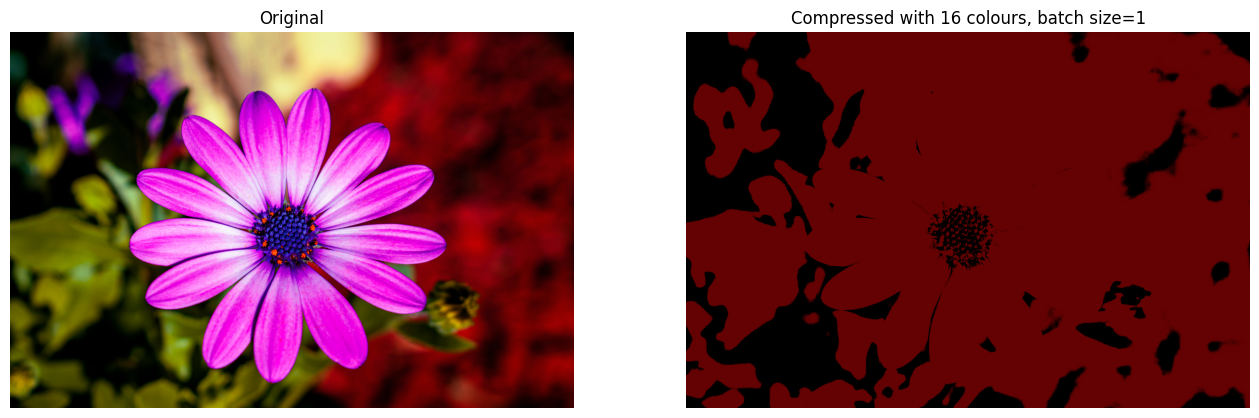

In [10]:
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(X_img)
ax[0].set_title('Original')
ax[0].set_axis_off()



ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours, batch size=%s' % (K, f'{batch_size:,}'))
ax[1].set_axis_off()

# Error VS Batch Size

In [11]:
def compute_cost(X,centroids,idx):
    
    cost=0.0

    for k in range(centroids.shape[0]):

        pts= X[idx==k]

        if len(pts)>0:
            cost+=np.sum((pts-centroids[k])**2)
    
    return cost/X.shape[0]

In [15]:
K=16
max_iterations=10

batch_size_array=[]
x=1

while x<=1e5:
    if x>=K:
        batch_size_array.append(x)    
    x*=2

initial_centroids=centroids_init(pixels,K)

cost_array=[]

for batch in batch_size_array:
    print("Running for i = ",batch)

    centroids_temp, idx_temp,X_batch_temp=kmeans(pixels,initial_centroids,max_iterations,batch)

    idx_full_temp=find_closest_centroids(pixels,centroids_temp)
   
    
    cost_array.append(compute_cost(pixels,centroids_temp,idx_full_temp))



Running for i =  16
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10
Running for i =  32
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10
Running for i =  64
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 10/10
Running for i =  128
K-MEANS ITERATION 1/10
K-MEANS ITERATION 2/10
K-MEANS ITERATION 3/10
K-MEANS ITERATION 4/10
K-MEANS ITERATION 5/10
K-MEANS ITERATION 6/10
K-MEANS ITERATION 7/10
K-MEANS ITERATION 8/10
K-MEANS ITERATION 9/10
K-MEANS ITERATION 1

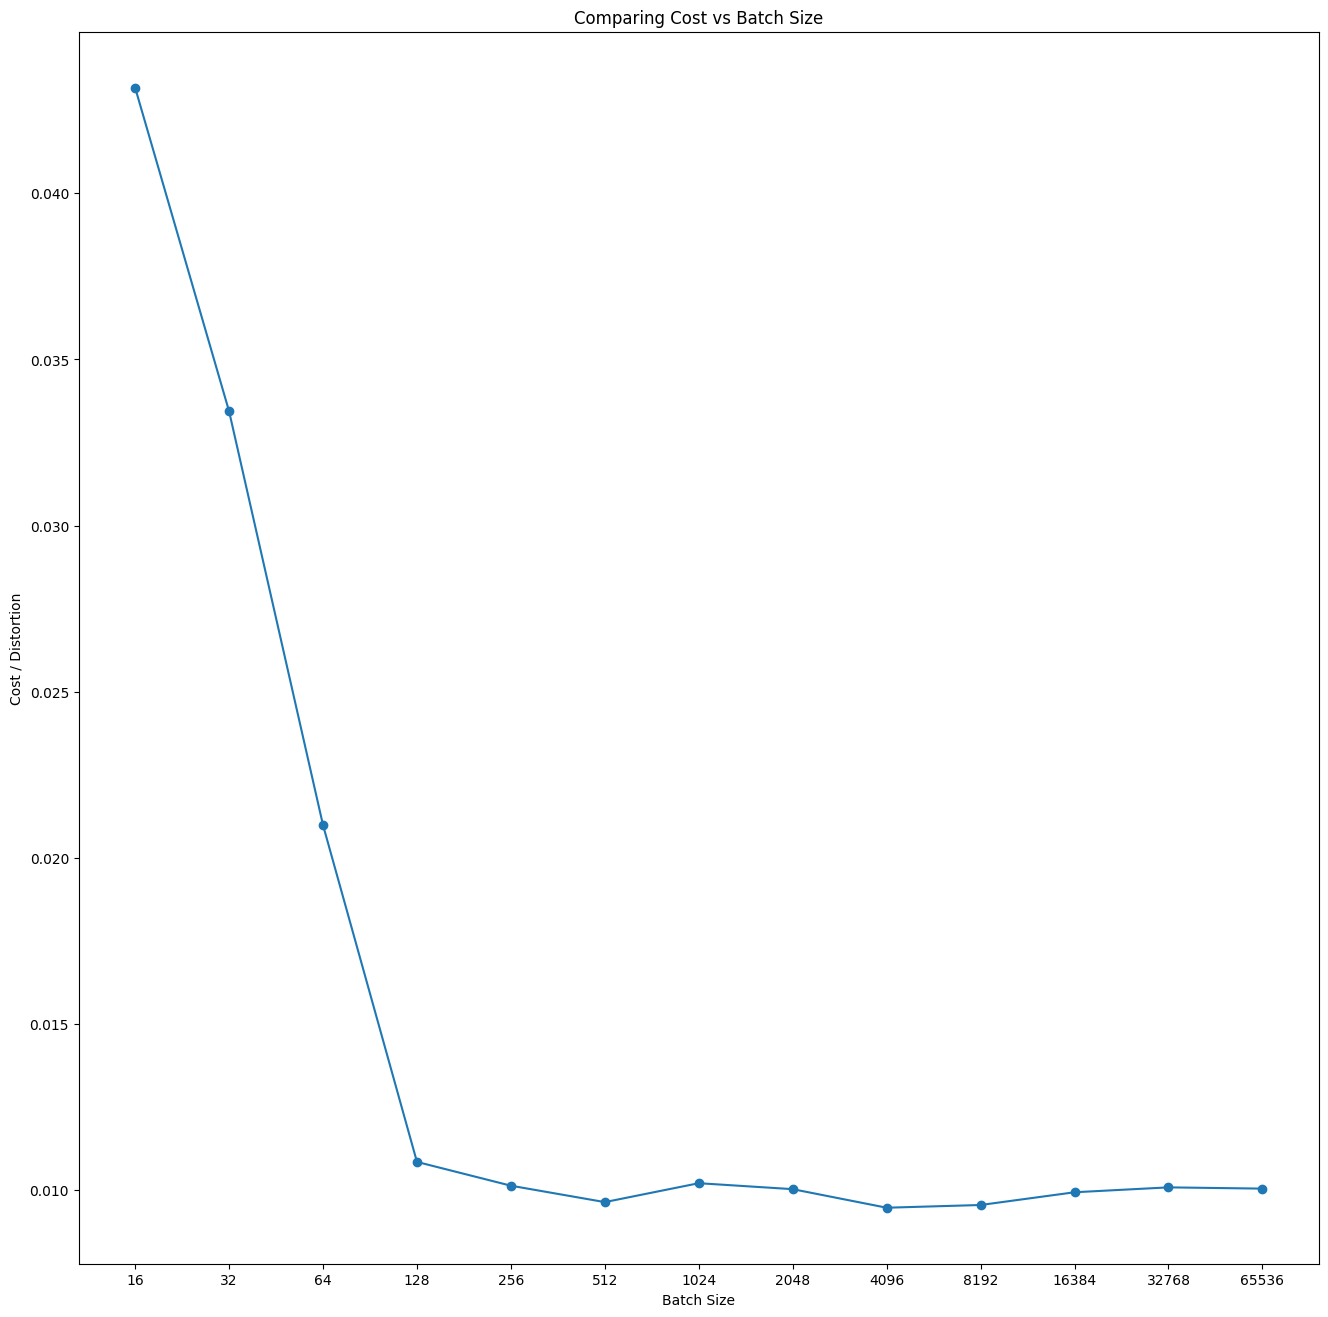

In [16]:
plt.figure(figsize=(16,16))

x = np.arange(len(batch_size_array))

plt.plot(x, cost_array, marker='o')

plt.xlabel("Batch Size")
plt.ylabel("Cost / Distortion")
plt.title("Comparing Cost vs Batch Size")

plt.xticks(x, batch_size_array)

plt.show()